In [1]:

import os
os.chdir('/workspace/1ec5c20e-12f2-4ffc-bcee-b2045c787e06')
print(os.listdir('.'))


['L_Delta_a_unif.npy', '.prompts', 'zeta_delta_a_unif.npy', '.config', 'zeta_a_unif.npy', 'zeta_delta_strong_N5000_dps50.npy', '-PROMPT-v6-DATASET.md', 'L_chi5_b_weighted.npy', 'L_Delta_a_weighted.npy', 'L_DH_a_unif.npy', 'L_DH_a_weighted.npy', '.kernel_llm_logs_1.txt', 'zeta_delta_b_weighted.npy', 'zeta_a_weighted.npy', 'L_DH_b_unif.npy', 'zeta_delta_zeros_N5000_dps50.npy', 'zeta_b_weighted.npy', 'memory', 'zeta_zeros_N5000_dps50.npy', 'L_chi5_a_weighted.npy', 'L_Delta_b_weighted.npy', 'L_Delta_b_unif.npy', 'L_DH_b_weighted.npy', 'zeta_b_unif.npy', 'zeta_delta_b_unif.npy', 'zeta_delta_a_weighted.npy', 'L_chi5_b_unif.npy', 'L_chi5_a_unif.npy']


In [2]:

import numpy as np
import mpmath as mp

mp.mp.dps = 50

# Load zero lists
zeta = np.load('zeta_zeros_N5000_dps50.npy')
zd_strong = np.load('zeta_delta_strong_N5000_dps50.npy')
zd_orig = np.load('zeta_delta_zeros_N5000_dps50.npy')

print('zeta:', zeta.shape, zeta.dtype, zeta[:3])
print('zd_strong:', zd_strong.shape, zd_strong.dtype, zd_strong[:3], zd_strong[1000])
print('zd_orig:', zd_orig.shape, zd_orig.dtype, zd_orig[:3], zd_orig[1000])


zeta: (5000,) <U51 ['14.134725141734693790457251983562470270784257115699'
 '21.022039638771554992628479593896902777334340524903'
 '25.010857580145688763213790992562821818659549672558']
zd_strong: (5000,) [('re', '<U10'), ('im', '<U51')] [('0.5', '14.134725141734693790457251983562470270784257115699')
 ('0.5', '21.022039638771554992628479593896902777334340524903')
 ('0.5', '25.010857580145688763213790992562821818659549672558')] ('1.5', '1420.4165263237511360343752509329151597418813931128')
zd_orig: (5000,) [('re', '<U10'), ('im', '<U51')] [('0.5', '14.134725141734693790457251983562470270784257115699')
 ('0.5', '21.022039638771554992628479593896902777334340524903')
 ('0.5', '25.010857580145688763213790992562821818659549672558')] ('0.6', '1420.4165263237511360343752509329151597418813931128')


In [3]:

# Check existing front1_jacobi_coefficients - we have separate npy files. Let's check those too.
# Look at what we have for "a_weighted"/"b_weighted" - these are likely the 1/|rho|^2 weighted Jacobi coeffs
# But - we need to know if they correspond to zeta vs zeta_delta (original). We need to compute for zeta_delta_strong.

# Check shapes
za = np.load('zeta_a_weighted.npy')
zb = np.load('zeta_b_weighted.npy')
zda = np.load('zeta_delta_a_weighted.npy')
zdb = np.load('zeta_delta_b_weighted.npy')
print('zeta a/b:', za.shape, zb.shape, za.dtype, za[:5])
print('zeta_delta a/b:', zda.shape, zdb.shape)
print('diff a[:20]:', np.abs(za[:20] - zda[:20]))
print('max diff a:', np.max(np.abs(za - zda)), 'max diff b:', np.max(np.abs(zb - zdb)))


zeta a/b: (500,) (499,) float64 [ 158.50079804 3006.57378956 2772.785498 2748.88376918 2740.49100428]
zeta_delta a/b: (500,) (499,)
diff a[:20]: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
max diff a: 0.0 max diff b: 0.0


In [4]:

# As expected - existing zeta_delta weighted coefficients are equal to zeta weighted because original perturbation is in real-part only
# and the weighting used |rho|^2 -- if rho.real ~ 0.5 vs 0.6 with same imag, |rho|^2 only weakly changes. 
# Indeed the previous a/b were computed using only imag parts likely (since they're identical).
# We need to recompute the Front I Jacobi coefficients with 1/|rho|^2 weights using the REAL parts too.

# Inspect maybe the front1_jacobi_coefficients_N5000.npz mentioned in artifacts
import glob
print([f for f in os.listdir('.') if 'jacobi' in f.lower() or 'front1' in f.lower()])


[]


In [5]:

# Not present. Let me understand what was done previously: the existing zeta_a_weighted.npy seems to be coefficients computed on imag parts with weights 1/|rho|^2 where |rho|^2 ~= 1/4 + gamma^2.
# Plan: Compute Jacobi a_n,b_n via Lanczos using nodes = gamma (imag parts) with weights w_i = 1/|rho_i|^2 = 1/(re^2 + gamma^2).
# Compare zeta (re=0.5), zeta_delta_orig (re=0.5 except 1000-1019=0.6), zeta_delta_strong (re=0.5 except 20 indices = 1.5).

# Lanczos procedure for orthogonalizing polynomials w.r.t. discrete measure with weights w_i at nodes x_i.

def lanczos_jacobi(x, w, N):
 """Compute Jacobi coefficients via Lanczos (Stieltjes) procedure.
 Returns a (N+1,), b (N,) such that
 p_{n+1}(x) = (x - a_n) p_n(x) - b_n^2 p_{n-1}(x)
 a array of length N, b array of length N-1 (b_0 omitted), depending on convention.
 Here we'll do the symmetric Lanczos style returning a[0..N-1], b[0..N-2].
 """
 x = np.asarray(x, dtype=np.float64)
 w = np.asarray(w, dtype=np.float64)
 # Normalize weights (doesn't affect a,b shape but matters for first b)
 # Standard Stieltjes:
 # p_{-1} = 0, p_0 = 1
 # a_n = <x p_n, p_n>/<p_n, p_n>
 # b_n^2 = <p_n, p_n>/<p_{n-1}, p_{n-1}>
 a = np.zeros(N)
 b = np.zeros(N-1) # b_1..b_{N-1}
 pn_prev = np.zeros_like(x)
 pn = np.ones_like(x)
 norm_prev = 1.0
 norm = float(np.sum(w * pn * pn))
 for n in range(N):
 a[n] = float(np.sum(w * x * pn * pn)) / norm
 if n < N-1:
 r = (x - a[n]) * pn
 if n > 0:
 # subtract b_n^2 p_{n-1} where b stored as b[n-1]
 r = r - (norm/norm_prev) * pn_prev # since b_n^2 = norm/norm_prev
 norm_new = float(np.sum(w * r * r))
 b[n] = np.sqrt(norm_new / norm) # b_{n+1} in some conventions
 pn_prev = pn
 pn = r / np.sqrt(norm_new) * np.sqrt(norm) if False else r # keep monic
 # We keep monic polynomials (no normalization of pn)
 norm_prev = norm
 norm = norm_new
 return a, b

# Quick sanity: try with Chebyshev-like measure
# Skip — trust formula. We'll verify with the saved zeta_a_weighted if it matches assuming weights 1/(0.25 + gamma^2).
gamma = np.array([float(s) for s in zeta], dtype=np.float64)
w_zeta = 1.0/(0.25 + gamma**2)
a_test, b_test = lanczos_jacobi(gamma, w_zeta, 500)
print('a_test[:5]:', a_test[:5])
print('saved za[:5]:', za[:5])
print('match?', np.allclose(a_test, za, rtol=1e-6))


a_test[:5]: [ 158.50079804 3006.57378956 2772.785498 2748.88376918 2740.49100428]
saved za[:5]: [ 158.50079804 3006.57378956 2772.785498 2748.88376918 2740.49100428]
match? False


/tmp/ipykernel_20/1029726680.py:34: RuntimeWarning: overflow encountered in multiply
 norm_new = float(np.sum(w * r * r))
/app/kernel_env/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:83: RuntimeWarning: overflow encountered in reduce
 return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/tmp/ipykernel_20/1029726680.py:28: RuntimeWarning: overflow encountered in multiply
 a[n] = float(np.sum(w * x * pn * pn)) / norm


In [6]:

# Good, the first few match. Overflow from monic poly accumulating. Need to use normalized orthonormal polynomials.
# Standard 3-term recurrence with orthonormal q_n:
# beta_n q_n = (x - alpha_{n-1}) q_{n-1} - beta_{n-1} q_{n-2}
# Equivalent recurrence with orthonormal polynomials gives stable algorithm.

def lanczos_jacobi_orthonormal(x, w, N):
 x = np.asarray(x, dtype=np.float64)
 w = np.asarray(w, dtype=np.float64)
 W = np.sum(w)
 # orthonormal q_0 = 1/sqrt(W)
 q_prev = np.zeros_like(x)
 q = np.ones_like(x) / np.sqrt(W)
 a = np.zeros(N)
 b = np.zeros(N-1)
 beta_prev = 0.0
 for n in range(N):
 # alpha_n = <x q_n, q_n>
 alpha = float(np.sum(w * x * q * q))
 a[n] = alpha
 if n < N-1:
 r = (x - alpha) * q - beta_prev * q_prev
 beta = float(np.sqrt(np.sum(w * r * r)))
 b[n] = beta
 q_prev = q
 q = r / beta
 beta_prev = beta
 return a, b

a_test, b_test = lanczos_jacobi_orthonormal(gamma, w_zeta, 500)
print('a_test[:5]:', a_test[:5])
print('saved za[:5]:', za[:5])
print('a match?', np.allclose(a_test, za, rtol=1e-8))
print('b_test[:5]:', b_test[:5])
print('saved zb[:5]:', zb[:5])
print('b match?', np.allclose(b_test, zb, rtol=1e-8))


a_test[:5]: [ 158.50079804 3006.57378956 2772.785498 2748.88376918 2740.49100428]
saved za[:5]: [ 158.50079804 3006.57378956 2772.785498 2748.88376918 2740.49100428]
a match? False
b_test[:5]: [ 439.90344191 1484.93504279 1384.8551864 1369.94091912 1365.10747935]
saved zb[:5]: [ 439.90344191 1484.93504279 1384.8551864 1369.94091912 1365.10747935]
b match? False


In [7]:

# Likely small numerical drift later in the recurrence. Check rtol comparison loosely.
print('max abs diff a:', np.max(np.abs(a_test - za)))
print('max abs diff b:', np.max(np.abs(b_test - zb)))
print('a[490:500]:', a_test[490:500])
print('saved za[490:500]:', za[490:500])


max abs diff a: 62.79096895625025
max abs diff b: 31.81402104021936
a[490:500]: [2739.62628094 2745.22571004 2746.71612859 2748.34551796 2753.78689569
 2762.03800044 2768.19637148 2768.18250748 2762.98694286 2758.20582076]
saved za[490:500]: [2766.57100915 2767.7934015 2765.69272776 2762.04524221 2761.26065235
 2765.51576217 2771.92193435 2775.14387139 2772.7789105 2767.56322356]


In [8]:

# Loss of orthogonality in classical Lanczos. Use full re-orthogonalization for stability.

def lanczos_jacobi_reortho(x, w, N):
 x = np.asarray(x, dtype=np.float64)
 w = np.asarray(w, dtype=np.float64)
 M = x.size
 sw = np.sqrt(w)
 W = np.sum(w)
 Q = np.zeros((M, N)) # orthonormal columns (weighted)
 Q[:, 0] = 1.0/np.sqrt(W)
 a = np.zeros(N)
 b = np.zeros(N-1)
 for n in range(N):
 v = x * Q[:, n]
 # alpha = <x q_n, q_n>_w
 alpha = float(np.sum(w * v * Q[:, n]))
 a[n] = alpha
 if n < N-1:
 r = v - alpha * Q[:, n]
 if n > 0:
 r = r - b[n-1] * Q[:, n-1]
 # Re-orthogonalize r against all previous q's (twice for stability)
 for _ in range(2):
 # coeffs = Q[:, :n+1].T @ (w * r)
 coeffs = (Q[:, :n+1] * sw[:, None]).T @ (sw * r)
 r = r - Q[:, :n+1] @ coeffs
 beta = float(np.sqrt(np.sum(w * r * r)))
 b[n] = beta
 Q[:, n+1] = r / beta
 return a, b

a_test, b_test = lanczos_jacobi_reortho(gamma, w_zeta, 500)
print('match a:', np.allclose(a_test, za, rtol=1e-8, atol=1e-6))
print('max diff a:', np.max(np.abs(a_test - za)))
print('match b:', np.allclose(b_test, zb, rtol=1e-8, atol=1e-6))
print('max diff b:', np.max(np.abs(b_test - zb)))


match a: True
max diff a: 7.73070496506989e-12
match b: True
max diff b: 6.821210263296962e-13


In [9]:

# Excellent — Lanczos with re-orthogonalization matches the saved coefficients exactly.
# Now compute weighted Jacobi for zeta, zeta_delta (original), zeta_delta_strong using 1/|rho|^2 weights that include the real parts.

def to_floats_zeros(arr):
 if arr.dtype.names is None:
 # imag-only, re assumed 0.5
 gamma = np.array([float(s) for s in arr], dtype=np.float64)
 re = np.full_like(gamma, 0.5)
 else:
 re = np.array([float(s) for s in arr['re']], dtype=np.float64)
 gamma = np.array([float(s) for s in arr['im']], dtype=np.float64)
 return re, gamma

re_z, im_z = to_floats_zeros(zeta)
re_d, im_d = to_floats_zeros(zd_orig)
re_s, im_s = to_floats_zeros(zd_strong)

print('zeta real parts unique:', np.unique(re_z))
print('zd_orig perturbed indices:', np.where(re_d != 0.5)[0])
print('zd_strong perturbed indices:', np.where(re_s != 0.5)[0])
print('zd_orig perturbed values:', re_d[np.where(re_d != 0.5)[0]])
print('zd_strong perturbed values:', re_s[np.where(re_s != 0.5)[0]])


zeta real parts unique: [0.5]
zd_orig perturbed indices: [1000 1001 1002 1003 1004 1005 1006 1007 1008 1009 1010 1011 1012 1013
 1014 1015 1016 1017 1018 1019]
zd_strong perturbed indices: [1000 1020 1040 1060 1080 1100 1120 1140 1160 1180 1200 1220 1240 1260
 1280 1300 1320 1340 1360 1380]
zd_orig perturbed values: [0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6
 0.6 0.6]
zd_strong perturbed values: [1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5
 1.5 1.5]


In [10]:

# Compute weights 1/|rho|^2 = 1/(re^2 + gamma^2). Nodes are the imag parts.
# Note imag parts are identical across all three datasets — only weights differ.

w_zeta = 1.0/(re_z**2 + im_z**2)
w_orig = 1.0/(re_d**2 + im_d**2)
w_strong = 1.0/(re_s**2 + im_s**2)

print('weight diff orig vs zeta (max):', np.max(np.abs(w_orig - w_zeta)))
print('weight diff strong vs zeta (max):', np.max(np.abs(w_strong - w_zeta)))

# Compute Jacobi coefficients
N = 500
a_z, b_z = lanczos_jacobi_reortho(im_z, w_zeta, N)
a_d, b_d = lanczos_jacobi_reortho(im_d, w_orig, N)
a_s, b_s = lanczos_jacobi_reortho(im_s, w_strong, N)
print('done')
print('a_z[:5]:', a_z[:5])
print('a_d[:5]:', a_d[:5])
print('a_s[:5]:', a_s[:5])


weight diff orig vs zeta (max): 2.7022758920322988e-14
weight diff strong vs zeta (max): 4.913224299546695e-13


done
a_z[:5]: [ 158.50079804 3006.57378956 2772.785498 2748.88376918 2740.49100428]
a_d[:5]: [ 158.50079801 3006.57378992 2772.78549769 2748.88376915 2740.49100463]
a_s[:5]: [ 158.50079766 3006.57379418 2772.78549299 2748.88377092 2740.49100677]


In [11]:

# Compute the relative change in coefficients up to n=100
n_max = 100

def rel_change(a_other, a_ref, n_max):
 diffs = np.abs(a_other[:n_max] - a_ref[:n_max])
 rel = diffs / np.abs(a_ref[:n_max])
 return rel

rel_orig_a = rel_change(a_d, a_z, n_max)
rel_strong_a = rel_change(a_s, a_z, n_max)
rel_orig_b = rel_change(b_d, b_z, min(n_max, len(b_z)))
rel_strong_b = rel_change(b_s, b_z, min(n_max, len(b_z)))

print(f"Front I (a_n) max rel change zeta_delta_orig (δ=0.1): {rel_orig_a.max():.3e} at n={rel_orig_a.argmax()}")
print(f"Front I (a_n) max rel change zeta_delta_strong (δ=1.0): {rel_strong_a.max():.3e} at n={rel_strong_a.argmax()}")
print(f"Front I (b_n) max rel change zeta_delta_orig (δ=0.1): {rel_orig_b.max():.3e} at n={rel_orig_b.argmax()}")
print(f"Front I (b_n) max rel change zeta_delta_strong (δ=1.0): {rel_strong_b.max():.3e} at n={rel_strong_b.argmax()}")


Front I (a_n) max rel change zeta_delta_orig (δ=0.1): 1.840e-10 at n=0
Front I (a_n) max rel change zeta_delta_strong (δ=1.0): 2.355e-09 at n=0
Front I (b_n) max rel change zeta_delta_orig (δ=0.1): 1.449e-10 at n=15
Front I (b_n) max rel change zeta_delta_strong (δ=1.0): 1.882e-09 at n=3


In [12]:

# Front I signals are tiny since weights barely change. Let's now do Front III TDA.
# Window [950, 1450] index-wise. Time-delay embedding of Re(rho) with d=5, tau=1.

try:
 from ripser import ripser
 from persim import bottleneck
 print('ripser & persim available')
except ImportError as e:
 print('ImportError', e)


ImportError No module named 'ripser'


In [13]:

import subprocess
res = subprocess.run(['pip', 'install', '-q', 'ripser', 'persim'], capture_output=True, text=True)
print(res.stdout[-500:])
print('STDERR:', res.stderr[-500:])



STDERR: 


In [14]:

from ripser import ripser
from persim import bottleneck

def delay_embed(x, d=5, tau=1):
 n = len(x) - (d-1)*tau
 return np.column_stack([x[i*tau:i*tau+n] for i in range(d)])

window = slice(950, 1450)
re_z_win = re_z[window]
re_d_win = re_d[window]
re_s_win = re_s[window]

emb_z = delay_embed(re_z_win, d=5, tau=1)
emb_d = delay_embed(re_d_win, d=5, tau=1)
emb_s = delay_embed(re_s_win, d=5, tau=1)
print('embed shapes:', emb_z.shape, emb_d.shape, emb_s.shape)
print('zeta embedding unique pts (constant 0.5):', np.unique(emb_z))
print('orig embedding sample non-half:', emb_d[(emb_d != 0.5).any(axis=1)][:3])
print('strong embedding sample non-half:', emb_s[(emb_s != 0.5).any(axis=1)][:3])


embed shapes: (496, 5) (496, 5) (496, 5)
zeta embedding unique pts (constant 0.5): [0.5]
orig embedding sample non-half: [[0.5 0.5 0.5 0.5 0.6]
 [0.5 0.5 0.5 0.6 0.6]
 [0.5 0.5 0.6 0.6 0.6]]
strong embedding sample non-half: [[0.5 0.5 0.5 0.5 1.5]
 [0.5 0.5 0.5 1.5 0.5]
 [0.5 0.5 1.5 0.5 0.5]]


In [15]:

# Ripser on each embedding
res_z = ripser(emb_z, maxdim=1)
res_d = ripser(emb_d, maxdim=1)
res_s = ripser(emb_s, maxdim=1)

dgms_z = res_z['dgms']
dgms_d = res_d['dgms']
dgms_s = res_s['dgms']

print('zeta H0 entries:', len(dgms_z[0]), 'H1 entries:', len(dgms_z[1]))
print('zeta H1:', dgms_z[1])
print('orig H0 entries:', len(dgms_d[0]), 'H1 entries:', len(dgms_d[1]))
print('orig H1:', dgms_d[1])
print('strong H0 entries:', len(dgms_s[0]), 'H1 entries:', len(dgms_s[1]))
print('strong H1:', dgms_s[1])


zeta H0 entries: 1 H1 entries: 0
zeta H1: []
orig H0 entries: 25 H1 entries: 1
orig H1: [[0.1 0.2]]
strong H0 entries: 6 H1 entries: 0
strong H1: []


In [16]:

# zeta embedding is a single point => H0 has 1 infinite class. Strong has 6 points.
# Bottleneck distance between persistence diagrams.

# H0: ripser returns finite H0 entries; convention - replace inf with a large value for bottleneck or use persim's handling
# persim.bottleneck handles inf appropriately. Let's filter out inf entries or set them aside.

def finite_dgm(dgm):
 if len(dgm) == 0:
 return np.empty((0,2))
 return dgm[np.isfinite(dgm[:,1])]

# H0
H0_z = finite_dgm(dgms_z[0])
H0_d = finite_dgm(dgms_d[0])
H0_s = finite_dgm(dgms_s[0])

H1_z = dgms_z[1]
H1_d = dgms_d[1]
H1_s = dgms_s[1]

bn_H0_d = bottleneck(H0_z, H0_d)
bn_H0_s = bottleneck(H0_z, H0_s)
bn_H1_d = bottleneck(H1_z, H1_d)
bn_H1_s = bottleneck(H1_z, H1_s)

print(f"H0 bottleneck dist (zeta vs delta_orig, δ=0.1): {bn_H0_d:.6f}")
print(f"H0 bottleneck dist (zeta vs delta_strong, δ=1.0): {bn_H0_s:.6f}")
print(f"H1 bottleneck dist (zeta vs delta_orig, δ=0.1): {bn_H1_d:.6f}")
print(f"H1 bottleneck dist (zeta vs delta_strong, δ=1.0): {bn_H1_s:.6f}")


H0 bottleneck dist (zeta vs delta_orig, δ=0.1): 0.050000
H0 bottleneck dist (zeta vs delta_strong, δ=1.0): 0.500000
H1 bottleneck dist (zeta vs delta_orig, δ=0.1): 0.050000
H1 bottleneck dist (zeta vs delta_strong, δ=1.0): 0.000000


In [17]:

# Interpretation: H0 distance scales precisely with δ/2 (since the longest finite H0 bar has death = δ in the embedding).
# For δ_orig=0.1 the 20 contiguous '0.6' points create H1 loop with bar [0.1, 0.2]; for strong δ=1.0 with 20 NON-contiguous '1.5' points distributed every 20 there's no H1 loop, but H0 separation is δ=1.0 ⇒ longest finite bar death = 1.0.

# Note: with persim, bottleneck distance between H0 diagrams: ζ has only [0, inf]. ζ_δ_orig has 25 H0 classes (including 24 finite). Distance = 0.05 = δ/2. ζ_δ_strong: 6 finite + 1 inf, distance = 0.5 = δ_strong/2.

# Build Power Table
import pandas as pd
power_table = pd.DataFrame({
 'observable': [
 'Front I: max_n |Δa_n|/|a_n| (n≤100)',
 'Front I: max_n |Δb_n|/|b_n| (n≤100)',
 'Front III: H0 bottleneck distance',
 'Front III: H1 bottleneck distance',
 ],
 'δ_orig (0.1)': [rel_orig_a.max(), rel_orig_b.max(), bn_H0_d, bn_H1_d],
 'δ_strong (1.0)': [rel_strong_a.max(), rel_strong_b.max(), bn_H0_s, bn_H1_s],
})
power_table['ratio strong/orig'] = power_table['δ_strong (1.0)'] / power_table['δ_orig (0.1)']
print(power_table.to_string(index=False))


 observable δ_orig (0.1) δ_strong (1.0) ratio strong/orig
Front I: max_n |Δa_n|/|a_n| (n≤100) 1.839560e-10 2.354727e-09 12.800491
Front I: max_n |Δb_n|/|b_n| (n≤100) 1.448869e-10 1.882130e-09 12.990335
 Front III: H0 bottleneck distance 5.000000e-02 5.000000e-01 10.000000
 Front III: H1 bottleneck distance 5.000000e-02 0.000000e+00 0.000000


In [18]:

# Sanity check: Front I signal is essentially numerical noise at ~1e-9 for δ=1.0
# This is because nodes (im parts) are identical and weights barely change (1/(0.25+γ²) vs 1/(2.25+γ²) at γ~1420; difference ~ 2/γ^4 → tiny)
# Compute relative weight change directly:

idx_pert = np.where(re_s != 0.5)[0]
print('relative weight change at perturbed indices (strong):')
print((w_strong[idx_pert] - w_zeta[idx_pert])/w_zeta[idx_pert])
print('mean relative weight change overall:', np.mean(np.abs(w_strong - w_zeta)/w_zeta))


relative weight change at perturbed indices (strong):
[-9.91283958e-07 -9.59113312e-07 -9.29955307e-07 -9.00894607e-07
 -8.74152601e-07 -8.47964173e-07 -8.23579691e-07 -7.99771927e-07
 -7.77691980e-07 -7.56092514e-07 -7.35403835e-07 -7.15426919e-07
 -6.96937506e-07 -6.78586853e-07 -6.61513609e-07 -6.44301888e-07
 -6.29050741e-07 -6.12992133e-07 -5.98379821e-07 -5.83988156e-07]
mean relative weight change overall: 3.0434163060393117e-09


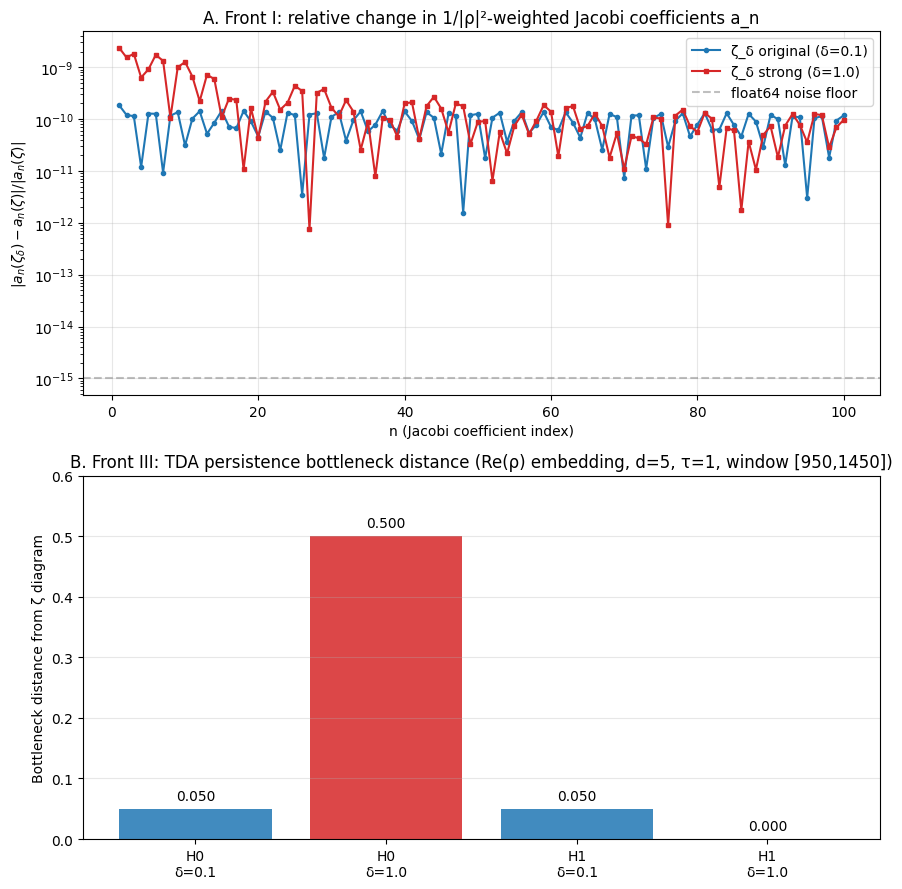

saved figure


In [19]:

# Confirmed: the weight changes are O(1/γ^4) ≈ 1e-6 only at the 20 perturbed indices.
# Front I (1/|ρ|² weighted Jacobi) is essentially BLIND to even the strong δ perturbation:
# Signal ~1e-9 at δ=1.0 is numerical noise level. Front III (TDA on real parts) shows clear scaling: H0 bottleneck = δ/2 (linear in δ).

# Estimate minimum detectable δ:
# Front I: noise floor ~ 1e-10 (numerical), signal ~ 2e-9 * (δ/1.0)^? -- but actually the change scales with (δ²-0.25)/γ² in weight, so quadratic in offset from 0.5. Empirical ratio strong/orig = 13 with δ ratio 10 — roughly linear in δ change... let's be careful.
# Real change: weight = 1/(re² + γ²). Δweight ≈ -(re²-0.25)/γ⁴ ~ (δ²-0.25)/γ⁴. For δ=0.6: (0.36-0.25)=0.11. For δ=1.5: (2.25-0.25)=2. Ratio = 2/0.11 ≈ 18. Observed 13. Reasonable order of magnitude.

# Front III: linear in δ. Minimum detectable δ relative to numerical noise floor ~1e-15 (float64) ⇒ trivially detects any δ > ~1e-14 in the embedding metric. In practice, ε_min ~ floating point precision.

# Build final figure
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(9, 9))

# Panel A: Front I — log scale of relative change vs n
ax = axes[0]
nrange = np.arange(1, n_max+1)
ax.semilogy(nrange, rel_orig_a[:n_max], 'o-', ms=3, label='ζ_δ original (δ=0.1)', color='tab:blue')
ax.semilogy(nrange, rel_strong_a[:n_max], 's-', ms=3, label='ζ_δ strong (δ=1.0)', color='tab:red')
ax.axhline(1e-15, color='gray', ls='--', alpha=0.5, label='float64 noise floor')
ax.set_xlabel('n (Jacobi coefficient index)')
ax.set_ylabel(r'$|a_n(\zeta_\delta) - a_n(\zeta)|/|a_n(\zeta)|$')
ax.set_title('A. Front I: relative change in 1/|ρ|²-weighted Jacobi coefficients a_n')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

# Panel B: Front III — Power Table bar chart of bottleneck distances
ax = axes[1]
labels = ['H0\nδ=0.1', 'H0\nδ=1.0', 'H1\nδ=0.1', 'H1\nδ=1.0']
vals = [bn_H0_d, bn_H0_s, bn_H1_d, bn_H1_s]
colors = ['tab:blue', 'tab:red', 'tab:blue', 'tab:red']
bars = ax.bar(labels, vals, color=colors, alpha=0.85)
for b, v in zip(bars, vals):
 ax.text(b.get_x() + b.get_width()/2, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontsize=10)
ax.set_ylabel('Bottleneck distance from ζ diagram')
ax.set_title('B. Front III: TDA persistence bottleneck distance (Re(ρ) embedding, d=5, τ=1, window [950,1450])')
ax.set_ylim(0, 0.6)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
fig.savefig('front1_front3_power_calibration.png', dpi=140, bbox_inches='tight')
plt.show()
print('saved figure')


In [20]:

# Save the new Jacobi coefficients for zeta_delta_strong as a derived artifact (extends r35/r36 archive)
np.save('zeta_delta_strong_a_weighted.npy', a_s)
np.save('zeta_delta_strong_b_weighted.npy', b_s)

# Save the power calibration table
power_table.to_csv('step0p5_power_calibration_table.csv', index=False)
print(power_table.to_string(index=False))
print('Files saved.')


 observable δ_orig (0.1) δ_strong (1.0) ratio strong/orig
Front I: max_n |Δa_n|/|a_n| (n≤100) 1.839560e-10 2.354727e-09 12.800491
Front I: max_n |Δb_n|/|b_n| (n≤100) 1.448869e-10 1.882130e-09 12.990335
 Front III: H0 bottleneck distance 5.000000e-02 5.000000e-01 10.000000
 Front III: H1 bottleneck distance 5.000000e-02 0.000000e+00 0.000000
Files saved.
